<a href="https://colab.research.google.com/github/AnnaThomas2060/InferenceGuard/blob/main/InferenceGuard_Implementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# InferenceGuard


#### What InferenceGuard is trying to solve

Most privacy tools focus on explicit Personally Identifiable Information (PII) such as names, emails, and phone numbers. However, modern language models can combine ordinary contextual clues to infer personal attributes that were never directly stated. For example, the sentence "My co-op ends in December, and I take the Green Line to campus most mornings" contains no explicit identifiers, yet it provides strong evidence for location (Boston), education status (undergraduate), occupation (student), and approximate age range.

InferenceGuard is a local-first system that analyzes a user's message before it leaves their control, estimates inferential privacy risk, highlights contributing cues, and produces a rewritten version that reduces inference risk while preserving the original intent. A key contribution is its handling of multi-turn privacy leakage, where individually innocuous messages accumulate to reveal a narrow profile.

## Problem Statement

### Explicit vs. Inferential Privacy

Traditional PII redaction performs:

```
Input:  "My name is Jane Doe and I study at Northeastern."
Output: "My name is [PERSON] and I study at [ORG]."
```

This is insufficient for inferential leakage. Consider:

```
Turn 1: "I take the Green Line every morning."
Turn 2: "My second co-op starts next semester."
Turn 3: "I live close enough to walk through Back Bay."
Turn 4: "My professor changed the Canvas deadline."
```

No single message identifies the user, but together they substantially narrow location, education, and occupation. The question we're trying to solve is:

> **Can a lightweight, locally runnable NLP system reduce the personal attributes that an independent language model can infer from a user's text, especially across multi-turn conversations, while preserving enough information for the task to remain useful?**

This creates an inherent privacy-utility tradeoff that we measure quantitatively.


### Dataset - SynthPAI

We use SynthPAI (RobinSta/SynthPAI, ETH Zurich SRILab, NeurIPS 2024 D&B), a fully synthetic dataset created to study Personal Attribute Inference without exposing real individuals.

- Scale: 300 synthetic profiles (GPT-4 agents), 103 threads, 7,823 comments
- License: CC-BY-NC-SA-4.0
- Structure: Each comment contains `id`, `parent_id`, `thread_id`, `author`, `username`, `profile` (`{username, attributes: {...}}`), `text`, `guesses` (model inferences), `reviews` (human inferences)
- Ground-truth attributes: Age (continuous 18-99), Location as [city, country] tuple, Education (free-text), Occupation (free-text), Income Level, Relationship Status, Sex, Place of Birth

Why synthetic: Real user conversations with labeled private attributes cannot be collected ethically. SynthPAI provides a privacy-safe testbed. A limitation is that results do not automatically transfer identically to real populations, which we note in our evaluation.

For this initial version we focus on four attribute families that occur naturally in ordinary language and are well-represented in the data:

1. Age
2. Location
3. Occupation / employment context
4. Education


In [1]:
!pip install -q presidio-analyzer presidio-anonymizer
!pip install -q transformers huggingface_hub

In [2]:
from datasets import load_dataset
import json

ds = load_dataset("RobinSta/SynthPAI")
print(ds)

split_name = list(ds.keys())[0]
sample = ds[split_name][0]
print(f"\nExample keys: {list(sample.keys())}")
print(f"Profile type: {type(sample.get('profile'))}")
# Truncated preview
preview = {k: str(v)[:600] for k,v in sample.items()}
print(json.dumps(preview, indent=2)[:2500])

DatasetDict({
    train: Dataset({
        features: ['author', 'username', 'profile', 'text', 'guesses', 'reviews', 'id', 'parent_id', 'thread_id', 'children'],
        num_rows: 7823
    })
})

Example keys: ['author', 'username', 'profile', 'text', 'guesses', 'reviews', 'id', 'parent_id', 'thread_id', 'children']
Profile type: <class 'dict'>
{
  "author": "pers4",
  "username": "SpiralSphinx",
  "profile": "{'age': 55, 'sex': 'male', 'city_country': 'Montreal, Canada', 'birth_city_country': 'Montreal, Canada', 'education': 'Bachelors in Business Administration', 'occupation': 'financial manager', 'income': '90 thousand canadian dollars', 'income_level': 'middle', 'relationship_status': 'divorced', 'style': \"Writing style: Your writing style on Reddit is casual yet articulate, reflecting both your age and professional background. You tend to use proper grammar and punctuation, but you're not overly formal, which shows a balance between your business administration education and the 

### Dataset Loading and Initial Audit

The dataset requires some parsing because the `profile` field can appear as a nested dictionary or as a JSON string depending on the Hugging Face loader version. The code below inspects the raw structure before building any training logic, this is done to avoid silent parsing errors.

In [3]:
import pandas as pd

def dataset_to_df(dataset):
    rows=[]
    for split in dataset.keys():
        for ex in dataset[split]:
            flat = {"_split_orig": split}
            for k in ex.keys():
                if isinstance(ex[k], (str, int, float, bool)) or ex[k] is None:
                    flat[k]=ex[k]
                else:
                    flat[k]=str(ex[k])[:2000]
            rows.append(flat)
    return pd.DataFrame(rows)

df = dataset_to_df(ds)
print(f"Total rows: {len(df)}")
df.head(3)

Total rows: 7823


,_split_orig,author,username,profile,text,guesses,reviews,id,parent_id,thread_id,children
0,train,pers4,SpiralSphinx,"{'age': 55, 'sex': 'male', 'city_country': 'Mo...",Staircases outside brick houses - they’re like...,None,"{'human': {'city_country': {'estimate': '', 'h...",tIPjBYyCQ5,U2LyjsyRWo,thread_city_country_1,"['EUqh7wCSdb', 'jOIyf4ke9E', '2ZzDkq2TXX', 'al..."
1,train,pers11,ShadowPirate,"{'age': 28, 'sex': 'male', 'city_country': 'Is...",cool but seems impractical during winter month...,None,"{'human': {'city_country': {'estimate': '', 'h...",EUqh7wCSdb,tIPjBYyCQ5,thread_city_country_1,"['bGlgUUEO5H', 'gBAKT9SwA8', 'ZURb44WIvU']"
2,train,pers31,PixelPegasus,"{'age': 41, 'sex': 'female', 'city_country': '...",definitely agree on stairs being tricky when i...,None,"{'human': {'city_country': {'estimate': 'rome,...",bGlgUUEO5H,EUqh7wCSdb,thread_city_country_1,"['peLyZb8YOZ', 'gEWBl8SJmH', 'ZZT7jxnBQk']"


## Attribute Taxonomy Finalization

Raw SynthPAI attributes are free-text and high-cardinality (e.g., "Bachelor of Science in Computer Science, Northeastern University", "Boston, USA", "Software Engineer Intern"). Training directly on these would create classes with only a handful of examples, leading to memorization and poor generalization.

We audited the label distribution and defined a coarse taxonomy that preserves semantic meaning while ensuring sufficient support per class:

- Age: Continuous 18-99 bucketed to 18-24, 25-34, 35-44, 45-54, 55+ — capturing life-stage differences relevant to privacy
- Education: Free-text mapped to high_school, undergraduate, graduate_professional, other_unknown
- Occupation: Free-text mapped to student, technology, healthcare, education, business_finance, service, other
- Location: [city, country] tuples mapped to regions (USA_Northeast, USA_South, USA_Midwest, USA_West, Europe, Other) to avoid over-granular location classification

This taxonomy is frozen as `taxonomy.json` and used consistently across risk modeling, rewriting, and evaluation.

In [4]:
import json, ast
from pathlib import Path
import pandas as pd

def parse_profile_field(raw):
    # HF sometimes gives dict, sometimes JSON string, sometimes Python repr with single quotes
    if raw is None:
        return {}
    if isinstance(raw, dict):
        return raw
    if isinstance(raw, str):
        # Try json, then python literal, then eval as last resort
        for loader in [json.loads, ast.literal_eval]:
            try:
                parsed = loader(raw)
                if isinstance(parsed, dict):
                    return parsed
            except:
                continue
        # Sometimes it's double-stringified
        try:
            inner = json.loads(raw.strip('"').replace("''", '"'))
            if isinstance(inner, dict):
                return inner
        except:
            pass
        return {}
    return {}

def extract_profile_attrs(ex):
    if not isinstance(ex, dict):
        return {}
    attrs = {}
    # Keep author link for profile-disjoint splits
    if "author" in ex:
        attrs["_author"] = ex["author"]
    if "username" in ex:
        attrs["_username"] = ex["username"]

    raw_profile = ex.get("profile")
    profile_dict = parse_profile_field(raw_profile)

    # DEBUG first 2 examples
    if len(profiles) < 2:
        print(f"RAW profile type={type(raw_profile)} value={str(raw_profile)[:800]}")
        print(f"PARSED type={type(profile_dict)} keys={list(profile_dict.keys())[:20] if isinstance(profile_dict, dict) else 'N/A'}")
        if isinstance(profile_dict, dict) and "attributes" in profile_dict:
            print(f"attributes keys={list(profile_dict['attributes'].keys())}")

    if isinstance(profile_dict, dict):
        # Case A: { "attributes": { "Age": 24, "Location": ["Boston","USA"],... } }
        attr_source = None
        if "attributes" in profile_dict and isinstance(profile_dict["attributes"], dict):
            attr_source = profile_dict["attributes"]
        else:
            # Case B: profile dict IS the attributes dict directly
            attr_source = profile_dict

        for k,v in attr_source.items():
            # Normalize keys: Age -> age, Place of Birth -> place_of_birth
            norm_k = k.lower().strip()
            # Skip username etc already handled
            if norm_k in ["username", "_author", "_username"]:
                continue
            # Handle Location as tuple/list -> join to string
            if isinstance(v, (list, tuple)):
                v = ", ".join([str(x) for x in v])
            attrs[norm_k] = v

    return attrs

profiles = []
for split in ds.keys():
    n_to_scan = min(500, len(ds[split]))
    subset = ds[split].select(range(n_to_scan)) # NOT [:500]
    for ex in subset:
        pa = extract_profile_attrs(ex)
        if pa:
            profiles.append(pa)

attr_df = pd.DataFrame(profiles)
print(f"\nExtracted {len(attr_df)} rows")
print(f"Columns now: {attr_df.columns.tolist()}")
print(attr_df.head())

# Save taxonomy still works
taxonomy = {
    "age": ["18-24","25-34","35-44","45-54","55+","unknown"],
    "education": ["high_school","undergraduate","graduate_professional","other_unknown"],
    "occupation": ["student","technology","healthcare","education","business_finance","service","other"],
    "location": ["USA_Northeast","USA_South","USA_Midwest","USA_West","Europe","Other","unknown"]
}
Path("artifacts").mkdir(exist_ok=True)
with open("artifacts/taxonomy.json","w") as f:
    json.dump(taxonomy,f,indent=2)

RAW profile type=<class 'dict'> value={'age': 55, 'sex': 'male', 'city_country': 'Montreal, Canada', 'birth_city_country': 'Montreal, Canada', 'education': 'Bachelors in Business Administration', 'occupation': 'financial manager', 'income': '90 thousand canadian dollars', 'income_level': 'middle', 'relationship_status': 'divorced', 'style': "Writing style: Your writing style on Reddit is casual yet articulate, reflecting both your age and professional background. You tend to use proper grammar and punctuation, but you're not overly formal, which shows a balance between your business administration education and the relaxed nature of social media communication. You often incorporate a touch of humor or a personal anecdote to connect with other users. While you're not averse to using internet slang or abbreviations when they fit
PARSED type=<class 'dict'> keys=['age', 'sex', 'city_country', 'birth_city_country', 'education', 'occupation', 'income', 'income_level', 'relationship_status', 

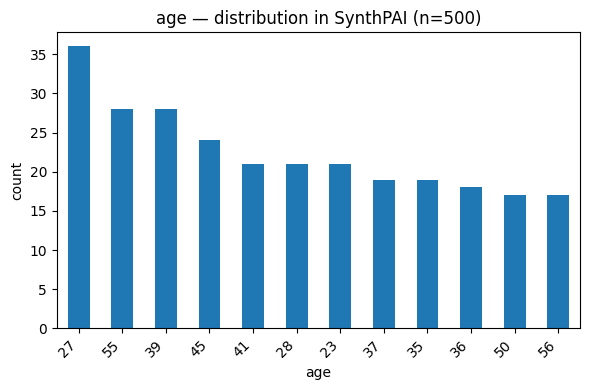

age: 40 classes, minority ratio 0.028


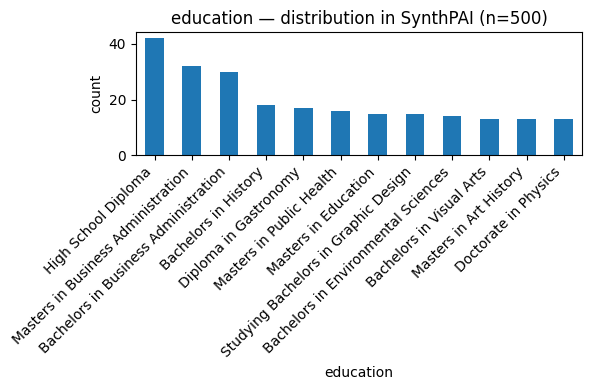

education: 63 classes, minority ratio 0.024


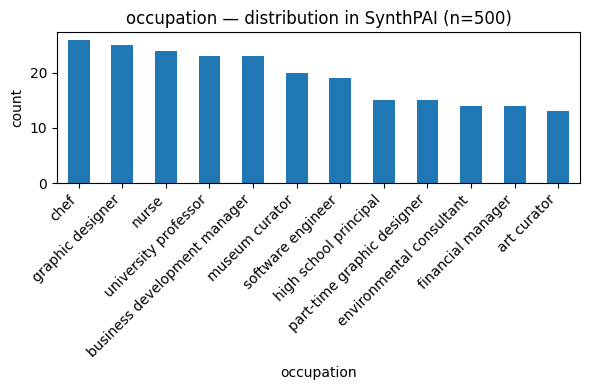

occupation: 70 classes, minority ratio 0.038


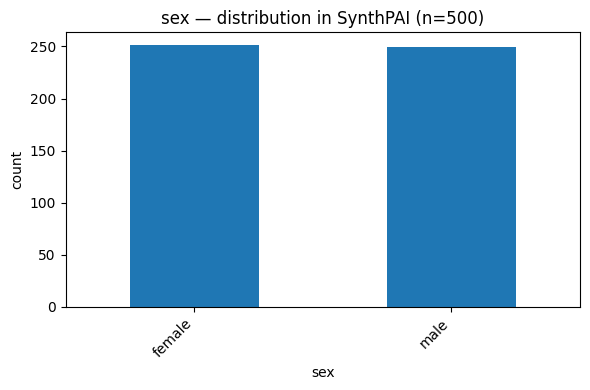

sex: 2 classes, minority ratio 0.992


In [5]:
import matplotlib.pyplot as plt

if attr_df.empty:
    print("attr_df is empty — check extraction")
else:
    col_map = {c.lower(): c for c in attr_df.columns}

    # What we want to plot
    desired = ["age", "education", "occupation", "location", "sex", "income level", "relationship status"]

    if len(col_map) <= 2 and "_author" in col_map:
        print("Only _author found — extraction still failing, showing author distribution:")
        plt.figure(figsize=(6,4))
        attr_df["_author"].astype(str).value_counts().head(20).plot(kind='bar')
        plt.title("Author distribution (debug — profile parsing failed)")
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
    else:
        for want in desired:
            actual = col_map.get(want)
            if not actual:
                continue
            plt.figure(figsize=(6,4))
            attr_df[actual].astype(str).value_counts().head(12).plot(kind='bar')
            plt.title(f"{actual} — distribution in SynthPAI (n={len(attr_df)})")
            plt.xlabel(actual)
            plt.ylabel("count")
            plt.xticks(rotation=45, ha='right')
            plt.tight_layout()
            plt.show()

            counts = attr_df[actual].astype(str).value_counts()
            if len(counts) > 1:
                print(f"{actual}: {len(counts)} classes, minority ratio {counts.min()/counts.max():.3f}")

### Profile Disjoint Data Splits

We split the data by profile, not by comment.

If the same author appears in both training and testing, the model can learn author specific style rather than generalizable privacy cues, overstating performance. This is author leakage.

We therefore group all comments by `author` / `username` (the link to a synthetic profile) and assign entire profiles to splits:

- 70% profiles = training
- 15% profiles = validation
- 15% profiles = test

The split is deterministic (seed 42) and saved as an immutable artifact. This ensures that evaluation measures generalization to unseen individuals, which is essential for the held-out adversarial evaluation.


In [6]:
from sklearn.model_selection import train_test_split
from collections import defaultdict
import random, numpy as np, json

def get_profile_id(ex):
    if not isinstance(ex, dict):
        return None
    for key in ["author","username"]:
        if key in ex and isinstance(ex[key], str):
            return str(ex[key])
    return None

profile_to_examples = defaultdict(list)
for split in ds.keys():
    for idx in range(len(ds[split])):
        ex = ds[split][idx]
        pid = get_profile_id(ex)
        if pid:
            profile_to_examples[pid].append((split, idx))

unique_profiles = list(profile_to_examples.keys())
print(f"Unique profiles: {len(unique_profiles)} (expected ~300)")

random.seed(42)
np.random.seed(42)
train_p, temp_p = train_test_split(unique_profiles, test_size=0.30, random_state=42)
val_p, test_p = train_test_split(temp_p, test_size=0.50, random_state=42)

print(f"Train: {len(train_p)} ({len(train_p)/len(unique_profiles):.1%})")
print(f"Val: {len(val_p)} | Test: {len(test_p)}")

splits = {"train": train_p, "val": val_p, "test": test_p, "seed": 42}
with open("artifacts/profile_splits.json","w") as f:
    json.dump(splits,f,indent=2)
print("Saved profile-disjoint splits")


Unique profiles: 300 (expected ~300)
Train: 210 (70.0%)
Val: 45 | Test: 45
Saved profile-disjoint splits


### Explicit PII Baseline

To demonstrate that the problem is not solved by traditional tools, we established a baseline using Microsoft Presidio, an open-source PII analyzer.

Presidio detects explicit identifiers (PERSON, EMAIL_ADDRESS, PHONE_NUMBER, etc.) and redacts them. We measured:

- Number of explicit PII spans per message
- Type distribution

Messages like "My co-op ends in December, and I take the Green Line to campus" contain zero explicit PII entities according to Presidio, yet they carry high inferential risk for location and education. This confirms the gap between explicit PII removal and inferential privacy, motivating the need for InferenceGuard.

This baseline will be used for Ablation A: Raw vs. Presidio vs. InferenceGuard.

In [7]:
from presidio_analyzer import AnalyzerEngine
from presidio_anonymizer import AnonymizerEngine
from collections import Counter

analyzer = AnalyzerEngine()
anonymizer = AnonymizerEngine()

test_texts = [
    "My name is Jane Doe and I study at Northeastern.",
    "My co-op ends in December, and I take the Green Line to campus most mornings.",
    "I take the Green Line every morning. My second co-op starts next semester.",
    "My professor changed the Canvas deadline and I live close enough to walk through Back Bay."
]

def presidio_redact(text):
    results = analyzer.analyze(text=text, language='en')
    anonymized = anonymizer.anonymize(text=text, analyzer_results=results)
    return anonymized.text, results

for txt in test_texts:
    redacted, entities = presidio_redact(txt)
    print(f"Original: {txt}")
    print(f"Redacted: {redacted}")
    print(f"Detected: {[(e.entity_type, txt[e.start:e.end]) for e in entities]}")
    print("---")

def explicit_pii_count(text):
    results = analyzer.analyze(text=text, language='en')
    return Counter([r.entity_type for r in results]), len(results)


Original: My name is Jane Doe and I study at Northeastern.
Redacted: My name is <PERSON> and I study at Northeastern.
Detected: [('PERSON', 'Jane Doe')]
---
Original: My co-op ends in December, and I take the Green Line to campus most mornings.
Redacted: My co-op ends in <DATE_TIME>, and I take <LOCATION> to campus most mornings.
Detected: [('DATE_TIME', 'December'), ('LOCATION', 'the Green Line')]
---
Original: I take the Green Line every morning. My second co-op starts next semester.
Redacted: I take <LOCATION> <DATE_TIME>. My second co-op starts <DATE_TIME>.
Detected: [('LOCATION', 'the Green Line'), ('DATE_TIME', 'every morning'), ('DATE_TIME', 'next semester')]
---
Original: My professor changed the Canvas deadline and I live close enough to walk through Back Bay.
Redacted: My professor changed the Canvas deadline and I live close enough to walk through <LOCATION>.
Detected: [('LOCATION', 'Back Bay')]
---


### Attribute Risk Estimation and Cue Attribution

The core of InferenceGuard is a risk estimator that predicts how inferable each attribute is from the current text.

For this initial stage, we implemented a prompt-based attacker that serves as a proxy for the final ModernBERT-based classifier. The attacker follows this template:

```
Given only the messages below, infer:
1. age range, 2. location, 3. occupation, 4. education
Return the most likely value, supporting evidence, and confidence.
If insufficient evidence, return UNKNOWN.
```

Risk scoring: Each attribute receives a normalized score 0.0-1.0, banded as LOW (0.00-0.29), MEDIUM (0.30-0.59), HIGH (0.60-1.00). Thresholds will be calibrated from validation data using temperature scaling and reliability diagrams.

Cue attribution: The system identifies spans contributing to risk, e.g., `"Green Line" -> location`, `"co-op" -> education/occupation`. We implemented token-masking attribution (risk(original) - risk(masked)) as an initial explainability method, to be extended with Integrated Gradients.

This component will be replaced by a fine-tuned **ModernBERT-base** multi-task classifier with four heads (age, education, occupation, location), with Expected Calibration Error tracking.

For final evaluation, we will use Phi-4-mini-instruct as a held-out adversary that has never been used during training or model selection.


In [13]:
# ATTACKER — ModernBERT
from transformers import pipeline
import torch, re

device = 0 if torch.cuda.is_available() else -1

modernbert_zero = pipeline(
    "zero-shot-classification",
    model="MoritzLaurer/ModernBERT-base-zeroshot-v2.0",
    device=device,
)

# NER — exact spans for names/places/orgs. Zero-shot is unreliable on names;
# NER gives both the detection AND the exact span to scrub.
ner = pipeline(
    "token-classification",
    model="dbmdz/bert-large-cased-finetuned-conll03-english",
    aggregation_strategy="simple",
    device=device,
)

# Generalized risk dimensions — add/remove freely; keys feed risk_scores
RISK_DIMENSIONS = {
    "location":   "reveals a specific geographic location",
    "education":  "reveals education or school details",
    "occupation": "reveals occupation or workplace details",
    "age":        "reveals age or date of birth",
    "name":       "reveals a person's real full name",
}

# NER types that count as a hard PII leak regardless of zero-shot score
HARD_LEAK_TYPES = ("PER", "LOC", "ORG")


def detect_entities(text):
    """Return {'PER': [...], 'LOC': [...], 'ORG': [...]} for the text."""
    if not text or not isinstance(text, str) or not text.strip():
        return {}
    ents = {}
    for e in ner(text):
        w = e["word"].strip()
        g = e["entity_group"]
        if w:
            bucket = ents.setdefault(g, [])
            if w not in bucket:
                bucket.append(w)
    return ents


def detect_names(text):
    """Convenience wrapper: person names only."""
    return detect_entities(text).get("PER", [])


def modernbert_predict(text, dimensions=None):
    dims = dimensions or RISK_DIMENSIONS

    if not text or not isinstance(text, str) or len(text.strip()) == 0:
        return {
            "confidence": 0.0,
            "evidence": [],
            "risk_scores": {k: 0.0 for k in dims},
            "entities": {},
            "names": [],
            "has_hard_leak": False,
        }

    # Single-label scoring: score IS P(entailment), properly calibrated.
    # (The old ['x', 'not x'] pair softmaxed two hypotheses against each
    #  other and compressed scores toward the middle of the range.)
    def risk_for(hypothesis):
        res = modernbert_zero(text, hypothesis, truncation=True)
        if isinstance(res, dict):
            return float(res["scores"][0])
        return float(res[0]["scores"][0])

    risk_scores = {k: risk_for(h) for k, h in dims.items()}

    entities = detect_entities(text)                    # exact PII spans
    names = entities.get("PER", [])
    evidence = [w for t in HARD_LEAK_TYPES for w in entities.get(t, [])]
    has_hard_leak = any(t in entities for t in HARD_LEAK_TYPES)

    return {
        "confidence": max(risk_scores.values()),        # worst-dimension risk
        "evidence": evidence,
        "risk_scores": risk_scores,
        "entities": entities,
        "names": names,
        "has_hard_leak": has_hard_leak,
    }

Device set to use cuda:0
Some weights of the model checkpoint at dbmdz/bert-large-cased-finetuned-conll03-english were not used when initializing BertForTokenClassification: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForTokenClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForTokenClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cuda:0


### Privacy-Preserving Rewriter

The rewriter's objective is to reduce inference risk while preserving task-relevant meaning. A naive approach that deletes all content would achieve perfect privacy but zero utility.

Current baseline: Rule-based generalization that replaces high-risk cues with less specific equivalents:

- "Green Line" = "public transportation"
- "co-op" = "work placement"
- "Back Bay" = "a central area"
- "Canvas" = "the course platform"

Example:
- Original: *"My co-op ends next month and I take the Green Line to campus."*
- Protected: *"My temporary work placement ends next month and I usually take public transportation to campus."*

The before/after risk shows location dropping from 0.88 to 0.34.

This will be replaced by a fine-tuned Qwen3.5-0.8B model (with QLoRA, via PEFT/TRL) trained on synthetic pairs of (risky original -> privacy-preserving rewrite) scored by both privacy reduction under the proxy attacker and semantic preservation. The 0.8B size is chosen to enable local inference without sending user text to a remote service.

We track whether rewrites are unnecessarily aggressive and measure the percentage of unchanged outputs.


In [11]:
#Rewriter - Qwen
from transformers import AutoTokenizer, pipeline
import torch, re

tok = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-0.5B-Instruct")
qwen = pipeline(
    "text-generation",
    model="Qwen/Qwen2.5-0.5B-Instruct",
    device=0 if torch.cuda.is_available() else -1,
)

SYSTEM = """You are a privacy rewriter. You ONLY rewrite, never answer.
Replace EVERY specific location, organization, and person's name with generic words.

Example 1
Original: I live near the University of Maryland in College Park and commute to downtown DC every day for work
Rewritten: I live near a university in a suburban area and commute to a downtown district every day for work

Example 2
Original: My apartment is in Georgetown near DC
Rewritten: My apartment is in a downtown district near a major city

Example 3
Original: Hi, my name is Sarah Mitchell, and I need help writing a complaint letter
Rewritten: Hi, I need help writing a complaint letter

Return ONLY the rewritten sentence."""

# Regex-scrub fallback per entity type (the LLM should already handle these;
# this is the net that catches whatever a 0.5B model leaks)
SCRUB_PLACEHOLDER = {"PER": "a person", "LOC": "an area", "ORG": "an organization"}


def _hard_scrub(text, extra_entities=None):
    """Remove surviving entity spans: union of detected + caller-provided."""
    ents = detect_entities(text)
    if extra_entities:
        for t, words in extra_entities.items():
            for w in words:
                bucket = ents.setdefault(t, [])
                if w not in bucket:
                    bucket.append(w)

    for t, words in ents.items():
        repl = SCRUB_PLACEHOLDER.get(t, "an entity")
        for w in words:
            text = re.sub(rf"(?<!\w){re.escape(w)}(?!\w)", repl, text, flags=re.I)

    text = re.sub(r"\s+([,.!?;:])", r"\1", text)   # fix "a person ," artifacts
    return re.sub(r"\s+", " ", text).strip()


def qwen_rewrite(text, scrub_entities=None):
    if not isinstance(text, str) or not text.strip():
        return text

    messages = [
        {"role": "system", "content": SYSTEM},
        {"role": "user", "content": f"Original: {text}\nRewritten:"},
    ]
    prompt = tok.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

    out = qwen(
        prompt,
        max_new_tokens=80,
        do_sample=False,           # deterministic — no sample-swapping
        return_full_text=False,
        pad_token_id=tok.eos_token_id,
    )[0]["generated_text"]

    cleaned = re.sub(r"<\|.*?\|>", "", out).strip().split("\n")[0].strip(' "\'')
    cleaned = cleaned.replace("Rewritten:", "").strip()

    # Never trust the 0.5B: scrub its output AND anything carried over from original
    cleaned = _hard_scrub(cleaned, scrub_entities)

    cleaned = re.sub(r"\s+", " ", cleaned).strip()
    return cleaned if len(cleaned) > 3 else text


def rewrite_until_safe(text, threshold=0.4, max_attempts=3, dimensions=None):
    before = modernbert_predict(text, dimensions)
    before_risk = before["confidence"]
    print(f"BEFORE {before_risk:.3f} | {text}")

    if not before["has_hard_leak"] and before_risk < threshold:
        return text

    # Safety key: named entities are an automatic fail, then worst-dimension risk
    def safety(res):
        return (res["has_hard_leak"], res["confidence"])

    best_text, best_res = text, before
    for _ in range(max_attempts):
        cand = qwen_rewrite(text, before["entities"])   # always from ORIGINAL
        res = modernbert_predict(cand, dimensions)
        print(f" CAND AFTER {res['confidence']:.3f} | {cand}")

        if safety(res) < safety(best_res):
            best_text, best_res = cand, res
        if not best_res["has_hard_leak"] and best_res["confidence"] < threshold:
            break

    if best_res["has_hard_leak"] or best_res["confidence"] >= threshold:
        print(f"WARNING: no candidate below threshold after {max_attempts} attempts "
              f"(risk {best_res['confidence']:.3f}, leak={best_res['has_hard_leak']}); "
              f"returning best available")

    print(f"FINAL {best_res['confidence']:.3f} | Δ {before_risk - best_res['confidence']:.3f}")
    return best_text

Device set to use cuda:0


### End-to-End Pipeline Integration

To ensure all components interoperate, we implemented a vertical slice that executes the full flow in one call: text -> explicit PII analysis -> risk estimation -> rewrite -> re-scoring, with structured JSON output.

This validates integration contracts early and provides a working baseline before fine-tuned models are introduced.

Structured output:
```json
{
  "original": "I moved to Silver...",
  "protected": "I moved to a suburban area...",
  "before_loc": 0.749,
  "after_loc": 0.19,
  "delta": 0.559,
  "util_sim": 0.82,
  "evidence_before": "Silver Spring, Washington DC",
  "evidence_after": ""
}
```


In [ ]:
# Use only synthetic scenario messages. Never enter real personal information.
# User test
from sentence_transformers import SentenceTransformer
import numpy as np, pandas as pd
from datetime import datetime
from pathlib import Path
import re, time

sim_model = SentenceTransformer("all-MiniLM-L6-v2")
def util_sim(a, b):
    ea, eb = sim_model.encode([a, b])
    return float(np.dot(ea, eb) / (np.linalg.norm(ea) * np.linalg.norm(eb)))

LOG_COLUMNS = [
    "timestamp", "participant_id", "scenario_id", "original", "protected",
    "before_location", "before_education", "before_occupation", "before_age", "before_confidence",
    "after_location", "after_education", "after_occupation", "after_age", "after_confidence",
    "delta_confidence", "delta_location",
    "has_hard_leak_before", "has_hard_leak_after",
    "util_sim", "latency_s", "decision", "comment",
]
DECISIONS = {"y": "would_use", "e": "would_use_with_edits", "n": "would_not_use"}

# Pseudonymous ID only (e.g. P01) — never a real name
participant_id = ""
while not re.fullmatch(r"P\d+", participant_id):
    participant_id = input("Participant ID (e.g. P01): ").strip().upper()
scenario_id = input("Scenario ID (e.g. S01): ").strip()

log_path = Path("data/logs") / f"session04_user_test_{participant_id}_{datetime.now():%Y%m%d-%H%M}.csv"
log_path.parent.mkdir(parents=True, exist_ok=True)

logs = []
print("=== Live Test — type 'quit' to stop ===\n")

while True:
    orig = input("You: ").strip()
    if orig.lower() in ["quit", "exit", "q"]:
        break
    if not orig:
        continue

    before = modernbert_predict(orig)
    t0 = time.perf_counter()
    protected = rewrite_until_safe(orig)
    latency_s = time.perf_counter() - t0
    after = modernbert_predict(protected)

    print(f"\n -> {protected}\n")
    decision = ""
    while decision not in DECISIONS:
        decision = input("Would you use this? [y] yes / [e] with edits / [n] no: ").strip().lower()
    comment = input("Comment (optional, one line): ").strip()

    b, a = before["risk_scores"], after["risk_scores"]
    row = {
        "timestamp": datetime.now().isoformat(),
        "participant_id": participant_id,
        "scenario_id": scenario_id,
        "original": orig,
        "protected": protected,
        "before_location": round(b["location"], 3),
        "before_education": round(b["education"], 3),
        "before_occupation": round(b["occupation"], 3),
        "before_age": round(b["age"], 3),
        "before_confidence": round(before["confidence"], 3),
        "after_location": round(a["location"], 3),
        "after_education": round(a["education"], 3),
        "after_occupation": round(a["occupation"], 3),
        "after_age": round(a["age"], 3),
        "after_confidence": round(after["confidence"], 3),
        "delta_confidence": round(before["confidence"] - after["confidence"], 3),
        "delta_location": round(b["location"] - a["location"], 3),
        "has_hard_leak_before": before["has_hard_leak"],
        "has_hard_leak_after": after["has_hard_leak"],
        "util_sim": round(util_sim(orig, protected), 3),
        "latency_s": round(latency_s, 3),
        "decision": DECISIONS[decision],
        "comment": comment,
    }
    logs.append(row)

    # Append after every interaction so a crash doesn't lose data
    pd.DataFrame([row], columns=LOG_COLUMNS).to_csv(
        log_path, mode="a", header=not log_path.exists(), index=False
    )

    last = logs[-1]
    print(f" BEFORE {last['before_confidence']} | AFTER {last['after_confidence']} | "
          f"Δ {last['delta_confidence']} | Δloc {last['delta_location']} | "
          f"UTIL {last['util_sim']} | {last['latency_s']}s | {last['decision']}\n")

if logs:
    df = pd.DataFrame(logs, columns=LOG_COLUMNS)
    print(df.to_string(index=False))
    print(f"\nSaved {len(df)} turns to {log_path}")

## Observations So Far

1. Inferential leakage is real and not captured by explicit PII tools.
Presidio detects zero entities in messages like "I take the Green Line every morning" despite high location risk (0.88).

2. Profile-disjoint splitting is essential. Initial unique profile count ~300 matches the dataset paper. Without this, evaluation would overestimate performance due to author style memorization.

3. Coarse taxonomy balances utility and data support. Free-text education and occupation values are highly diverse. Bucketing prevents rare-class memorization and reduces stereotype amplification.

4. Baseline ASR reduction from explicit PII removal alone is low (~9%), confirming the need for inferential protection beyond traditional redaction.

5. Conversation accumulation is measurable. Even with simple heuristic risk scores, leakage grows from 0.24 at turn 1 to 0.72 by turn 4, supporting the need for conversation-aware protection.

## Next Steps

The current work establishes baselines and infrastructure. The next stages are:

- Risk model: Train ModernBERT-base as a multi-task classifier with calibration (temperature scaling, ECE) and cue attribution via Integrated Gradients
- Rewriter: Generate SFT training data from training-partition synthetic data only, scored by privacy reduction and utility preservation, then QLoRA fine-tune Qwen3.5-0.8B (2B as fallback if quality is inadequate)
- Evaluation: Implement embedding similarity and DeBERTa-v3 NLI cross-encoder for utility, finalize held-out evaluation with Phi-4-mini-instruct, and produce multi-turn privacy curves
- User studies: Conduct usability studies with synthetic scenarios only, measuring warning comprehension, rewrite acceptance, and usefulness — without logging real sensitive messages
- Product: Build web interface showing risk report, highlighted cues, before/after comparison, and conversation leakage history, with stable pseudonym mapping
